In [19]:
import tensorflow as tf
from tensorflow.keras import mixed_precision, layers, Model, Input, backend as K
from tensorflow.keras.optimizers import Adam
import numpy as np
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import os
from scipy import stats
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample, class_weight


In [20]:
try:
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
    print(f"🚀 Mixed Precision activado. Compute dtype: {policy.compute_dtype}")
except Exception as e:
    print("⚠️ No se pudo activar Mixed Precision (quizás no tienes GPU NVIDIA disponible).")

🚀 Mixed Precision activado. Compute dtype: float16


In [21]:
# --- CAPA DE ATENCIÓN ---
class AttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    
    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return K.sum(output, axis=1)

In [22]:
# --- BLOQUE INCEPTION RESIDUAL SEPARABLE (La Joya) ---
def residual_inception_block(x, filters):
    """
    Combina: Inception (Multi-escala) + SeparableConv (Eficiencia) + Residual (Flujo)
    """
    # Guardamos la entrada para la conexión residual
    shortcut = x
    
    # --- RAMAS INCEPTION ---
    # Rama A: Kernel 1 (Relación entre sensores)
    branch_a = layers.Conv1D(filters, 1, padding='same', use_bias=False)(x)
    branch_a = layers.BatchNormalization()(branch_a)
    branch_a = layers.Activation('relu')(branch_a)

    # Rama B: Kernel 3 (Corto plazo) -> Separable!
    branch_b = layers.SeparableConv1D(filters, 3, padding='same', use_bias=False)(x)
    branch_b = layers.BatchNormalization()(branch_b)
    branch_b = layers.Activation('relu')(branch_b)

    # Rama C: Kernel 5 (Largo plazo) -> Separable!
    branch_c = layers.SeparableConv1D(filters, 5, padding='same', use_bias=False)(x)
    branch_c = layers.BatchNormalization()(branch_c)
    branch_c = layers.Activation('relu')(branch_c)

    # Concatenar ramas
    x = layers.Concatenate(axis=-1)([branch_a, branch_b, branch_c])
    
    # --- PROYECCIÓN RESIDUAL ---
    # La salida concatenada tiene 3*filters canales. La entrada 'shortcut' tiene menos.
    # Necesitamos una Conv1D(1x1) para igualar dimensiones antes de sumar.
    shortcut = layers.Conv1D(3 * filters, 1, padding='same', use_bias=False)(shortcut)
    shortcut = layers.BatchNormalization()(shortcut)
    
    # SUMA RESIDUAL
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    
    return x

In [23]:
# --- MODELO PRINCIPAL ---
def build_chollet_pro_model(input_shape, num_classes, learning_rate=1e-3):
    
    inputs = Input(shape=input_shape, name="emg_input")
    
    # 1. Adaptación inicial
    x = layers.Conv1D(32, 1, padding='same')(inputs) # Proyectar a 32 filtros
    
    # 2. Bloque 1: Extracción Profunda
    x = residual_inception_block(x, filters=32)
    x = layers.MaxPooling1D(2)(x) # Reducir tiempo 40 -> 20
    x = layers.Dropout(0.2)(x)
    
    # 3. Bloque 2: Profundidad (Opcional, pero Chollet dice "Deep is better")
    # Aumentamos filtros a 64 (Regla: Filters increase as size decreases)
    x = residual_inception_block(x, filters=64)
    x = layers.MaxPooling1D(2)(x) # Reducir tiempo 20 -> 10
    x = layers.Dropout(0.3)(x)
    
    # 4. Memoria Temporal (Bi-LSTM)
    # Ahora la secuencia es corta (10 pasos) pero muy rica en features (192 canales)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    
    # 5. Atención
    x = AttentionLayer()(x)
    
    # 6. Clasificador
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs, name="MyoTensorNet")
    model.compile(optimizer=Adam(learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

In [24]:
# Verificación de parámetros
model = build_chollet_pro_model((40, 8), 7)
model.summary()

Model: "MyoTensorNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ emg_input           │ (None, 40, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 40, 32)    │        288 │ emg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 40, 32)    │      1,024 │ conv1d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_8  │ (None, 40, 32)    │      1,120 │ conv1d_10[0][0]   │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_9  │ (None, 40, 32)    │      1,184 │ conv1d_10[0][0]   │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 32)    │        128 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 32)    │        128 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 32)    │        128 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 40, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 40, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 40, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 40, 96)    │      3,072 │ conv1d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 40, 96)    │          0 │ activation_16[0]… │
│ (Concatenate)       │                   │            │ activation_17[0]… │
│                     │                   │            │ activation_18[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 96)    │        384 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 40, 96)    │          0 │ concatenate_4[0]… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 40, 96)    │          0 │ add_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 20, 96)    │          0 │ activation_19[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 392,753 (1.50 MB)

 Trainable params: 391,473 (1.49 MB)

 Non-trainable params: 1,280 (5.00 KB)

⏳ Cargando datos ORIGINALES...

⚖️ PESOS CALCULADOS (Castigo por error):
   Gesto 0: 0.24x
   Gesto 1: 1.68x
   Gesto 2: 2.33x
   Gesto 3: 2.09x
   Gesto 4: 2.02x
   Gesto 5: 2.29x
   Gesto 6: 2.32x
⚙️ Creando tuberías de datos (tf.data)...
🚀 Iniciando entrenamiento en GPU con optimizaciones...
Epoch 1/100
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4850 - loss: 2.0594
Epoch 1: val_accuracy improved from None to 0.71257, saving model to ../models/myotensor_net.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5896 - loss: 2.0801 - val_accuracy: 0.7126 - val_loss: 1.1842 - learning_rate: 0.0010
Epoch 2/100
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6364 - loss: 2.1738
Epoch 2: val_accuracy improved from 0.71257 to 0.77153, saving model to ../models/myotensor_net.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6659 - loss: 1.8403 - val_accuracy: 0.7715 - val_loss: 0.6680 - learning_rate: 0.0010
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

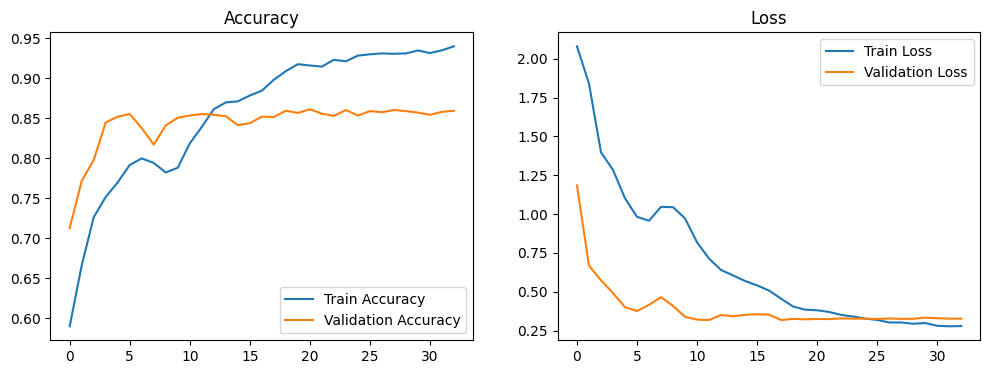


--- Evaluación Final en Test Set ---
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8517 - loss: 0.3176
🏆 Test Accuracy: 85.17%


In [25]:
# 1. Cargar Datos COMPLETOS (Originales, sin balancear/recortar)
print("⏳ Cargando datos ORIGINALES...")
base_path = '../datasets/processed'
X_train = np.load(f'{base_path}/X_train.npy')
y_train = np.load(f'{base_path}/y_train.npy')
X_test  = np.load(f'{base_path}/X_test.npy')
y_test  = np.load(f'{base_path}/y_test.npy')

# 2. Calcular los "Pesos" (La importancia de cada gesto)
# Primero necesitamos las etiquetas como enteros (0, 1, 2...) no one-hot
y_integers = np.argmax(y_train, axis=1)
classes = np.unique(y_integers)

# Scikit-learn calcula el peso ideal para equilibrar todo
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_integers
)

# Lo convertimos a un diccionario {0: 0.5, 1: 2.3, ...} que Keras entienda
class_weight_dict = dict(enumerate(class_weights))

print("\n⚖️ PESOS CALCULADOS (Castigo por error):")
for gest_id, weight in class_weight_dict.items():
    print(f"   Gesto {gest_id}: {weight:.2f}x")
# Verás que el Gesto 0 tendrá un peso bajo (ej: 0.2) y el Gesto 4 uno alto (ej: 3.5)

# 3. Configurar Dataset (Igual que antes, pero con datos completos)
BATCH_SIZE = 128
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = (train_dataset
                 .shuffle(buffer_size=1024)
                 .batch(BATCH_SIZE)
                 .cache()
                 .prefetch(tf.data.AUTOTUNE))

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)


# --- OPTIMIZACIÓN 2: DATA PIPELINE (tf.data) ---
# Esto evita que la GPU espere a la CPU. Prepara los datos en paralelo.
print("⚙️ Creando tuberías de datos (tf.data)...")

# 3. Callbacks
callbacks = [
    ModelCheckpoint(
        filepath='../models/myotensor_net.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    ),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# 4. Entrenar
print("🚀 Iniciando entrenamiento en GPU con optimizaciones...")

# NOTA: Pasamos los 'datasets' en lugar de X_train, y_train
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=100,             # Dale tiempo, ahora le costará más bajar el error
    callbacks=callbacks,
    class_weight=class_weight_dict, # <--- ¡AQUÍ ESTÁ LA MAGIA!
    verbose=1
)

# 5. Visualizar Resultados
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Loss')
    plt.show()

plot_history(history)

# 6. Evaluación Final
print("\n--- Evaluación Final en Test Set ---")
loss, accuracy = model.evaluate(test_dataset) # Usamos test_dataset aquí también
print(f"🏆 Test Accuracy: {accuracy*100:.2f}%")

🔮 Generando predicciones...
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
🧹 Aplicando Majority Voting (Ventana de 5)...

--- RESULTADOS IMPACTANTES ---
🎯 Accuracy Cruda (Ventana a Ventana): 85.17%
🚀 Accuracy Suavizada (Experiencia de Usuario): 84.57%


<Figure size 1000x800 with 0 Axes>

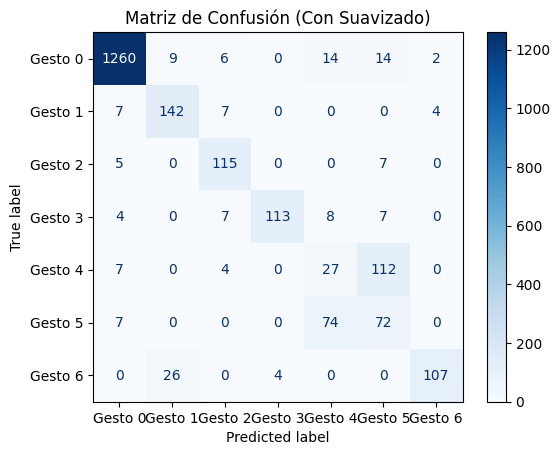


--- Reporte por Gesto ---
              precision    recall  f1-score   support

     Gesto 0       0.98      0.97      0.97      1305
     Gesto 1       0.80      0.89      0.84       160
     Gesto 2       0.83      0.91      0.86       127
     Gesto 3       0.97      0.81      0.88       139
     Gesto 4       0.22      0.18      0.20       150
     Gesto 5       0.34      0.47      0.39       153
     Gesto 6       0.95      0.78      0.86       137

    accuracy                           0.85      2171
   macro avg       0.73      0.71      0.72      2171
weighted avg       0.86      0.85      0.85      2171



In [26]:
# 1. Obtener predicciones crudas del Test Set
print("🔮 Generando predicciones...")
# Usamos el dataset de prueba optimizado que ya tienes
y_pred_prob = model.predict(test_dataset) 
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = np.argmax(y_test, axis=1) 

# 2. Función de Majority Voting (Suavizado)
def apply_majority_voting(predictions, window_size=5):
    """
    Simula el post-procesamiento en tiempo real.
    Si window_size=5, toma la decisión basándose en las últimas 5 ventanas.
    """
    smoothed_preds = []
    for i in range(len(predictions)):
        # Tomar los últimos N valores
        start_idx = max(0, i - window_size + 1)
        window = predictions[start_idx : i + 1]
        
        # Calcular la moda
        mode_result = stats.mode(window, keepdims=False)[0]
        smoothed_preds.append(mode_result)
        
    return np.array(smoothed_preds)

# 3. Aplicar el filtro
print("🧹 Aplicando Majority Voting (Ventana de 5)...")
y_pred_smoothed = apply_majority_voting(y_pred_classes, window_size=5)

# 4. Comparar Resultados
acc_raw = accuracy_score(y_true_classes, y_pred_classes)
acc_smooth = accuracy_score(y_true_classes, y_pred_smoothed)

print(f"\n--- RESULTADOS IMPACTANTES ---")
print(f"🎯 Accuracy Cruda (Ventana a Ventana): {acc_raw*100:.2f}%")
print(f"🚀 Accuracy Suavizada (Experiencia de Usuario): {acc_smooth*100:.2f}%")

# 5. Matriz de Confusión (Versión Matplotlib puro)
class_names = [f'Gesto {i}' for i in range(7)]

# Calculamos la matriz
cm = confusion_matrix(y_true_classes, y_pred_smoothed)

# La dibujamos
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Matriz de Confusión (Con Suavizado)')
plt.show()

# Reporte detallado
print("\n--- Reporte por Gesto ---")
print(classification_report(y_true_classes, y_pred_smoothed, target_names=class_names))